<a href="https://colab.research.google.com/github/Zee5h4n/lessons-learned/blob/Plan-Disease-recogition-by-using-tranformar/plan_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Plan Disease recogition by using tranformar**

In [1]:
#Import librieres
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import zipfile
import random
from pathlib import Path
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models
import timm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
#Gdrive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/plant.zip'
extract_path = '/content/plant_disease_data'

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract zip file
print("Extracting ZIP file...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Extracting ZIP file...
Files extracted to: /content/plant_disease_data


In [4]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files)-3} more files')

plant_disease_data/
  Train/
    Train/
      Healthy/
        97d96fd68296801e.jpg
        82fc37c398513727.jpg
        89d12bd9a3678da2.jpg
        ... and 455 more files
      Powdery/
        bd3e64f2da30c324.jpg
        83217f38e476ce52.jpg
        ba62680dcf379178.jpg
        ... and 427 more files
      Rust/
        b0a3901b244fe3ef.jpg
        e38b8323da1e8fc2.jpg
        a5d042c32bc737ab.jpg
        ... and 431 more files
  Test/
    Test/
      Healthy/
        8ed6fe1f030281d7.jpg
        8f137ee1d4f01a58.jpg
        8e7e70a6878c1c79.jpg
        ... and 47 more files
      Powdery/
        84bc36cccfa42b6a.jpg
        85ec3f0705065df9.jpg
        85b53e9c21a1f82f.jpg
        ... and 47 more files
      Rust/
        95fcc0d888c1b9bb.jpg
        831abdc76c05e23d.jpg
        88e3af0caa9e497c.jpg
        ... and 47 more files
  Validation/
    Validation/
      Healthy/
        9c3f1c10ba54ed56.jpg
        9d6a6499354e3197.jpg
        9ce01ba1856fc6ad.jpg
        ... and 17 mo

In [5]:
#Data Exploration
data_dir = os.path.join(extract_path, 'Train', 'Train')

# Get class names
class_names = sorted(os.listdir(data_dir))
num_classes = len(class_names)

print(f"\n{'='*70}")
print(f"DATASET INFORMATION")
print(f"{'='*70}")
print(f"Number of Classes: {num_classes}")
print(f"\nClass Names:")
for idx, name in enumerate(class_names, 1):
    print(f"{idx:2d}. {name}")


DATASET INFORMATION
Number of Classes: 3

Class Names:
 1. Healthy
 2. Powdery
 3. Rust


In [6]:
#count images par class
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    count = len([f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[class_name] = count

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False)

print(f"\n{'='*70}")
print("Images per Class:")
print(df_counts.to_string(index=False))
print(f"\nTotal Images: {df_counts['Count'].sum()}")
print(f"Average per Class: {df_counts['Count'].mean():.0f}")


Images per Class:
  Class  Count
Healthy    458
   Rust    434
Powdery    430

Total Images: 1322
Average per Class: 441


In [7]:
#DATASET CLASS
class PlantDiseaseDataset(Dataset):
    """Custom Dataset for Plant Disease Images"""

    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        # Collect all image paths and labels
        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_dir, img_name)
                    self.images.append(img_path)
                    self.labels.append(class_idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']

        return image, label

In [8]:
#get class member by using object
model = PlantDiseaseDataset

In [9]:
model

__main__.PlantDiseaseDataset

In [10]:
#DATA AUGMENTATION
IMG_SIZE = 224  # Standard for Vision Transformer

# TRAINING Transforms (WITH Augmentation)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=40, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0)),
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MotionBlur(blur_limit=5),
    ], p=0.3),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean (normalization)
        std=[0.229, 0.224, 0.225]     # ImageNet std
    ),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1374347779.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


In [11]:
# VALIDATION/TEST Transforms
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print("Data augmentation pipelines created!")
print("  - Training: WITH augmentation + normalization")
print("  - Validation/Test: WITHOUT augmentation, ONLY normalization")


Data augmentation pipelines created!
  - Training: WITH augmentation + normalization
  - Validation/Test: WITHOUT augmentation, ONLY normalization


In [12]:
# SECTION 7: CREATE DATASETS AND DATALOADERS
full_dataset = PlantDiseaseDataset(data_dir, transform=None)

# Split into train, val, test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [13]:
#  Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

In [14]:
#  Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n{'='*70}")
print("DATASET SPLITS")
print(f"{'='*70}")
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Number of classes:  {num_classes}")


DATASET SPLITS
Training samples:   925
Validation samples: 198
Test samples:       199
Batch size:         32
Number of classes:  3


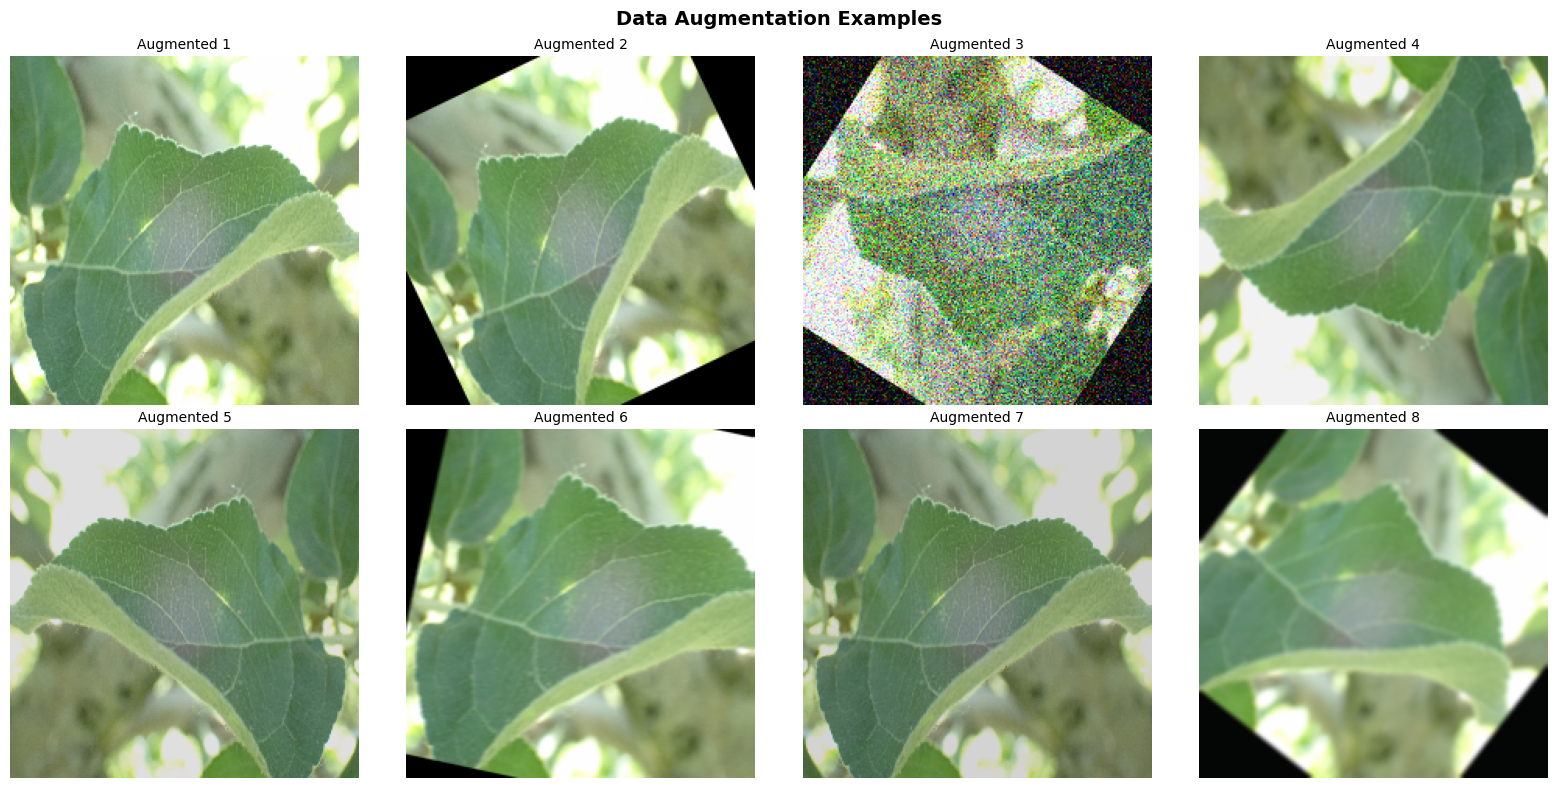

Augmentation visualization saved!


In [15]:
# VISUALIZE AUGMENTATION
def visualize_augmentation(dataset, num_samples=8):
    """Show augmentation effects"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # Get a sample image
    sample_idx = random.randint(0, len(dataset)-1)
    img_path = dataset.dataset.images[sample_idx]
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    for idx in range(num_samples):
        # Apply augmentation
        transformed = train_transform(image=original_img)
        aug_img = transformed['image']

        # Convert tensor to image for display
        aug_img = aug_img.permute(1, 2, 0).numpy()
        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        aug_img = std * aug_img + mean
        aug_img = np.clip(aug_img, 0, 1)

        axes[idx].imshow(aug_img)
        axes[idx].axis('off')
        axes[idx].set_title(f'Augmented {idx+1}', fontsize=10)

    plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/augmentation_pytorch.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Augmentation visualization saved!")

visualize_augmentation(train_dataset)

In [16]:
#Vision Transformer model
class PlantDiseaseViT(nn.Module):

    def __init__(self, num_classes, model_name='vit_base_patch16_224', pretrained=True):
        super(PlantDiseaseViT, self).__init__()

        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [17]:
PlantDiseaseViT

__main__.PlantDiseaseViT

In [18]:
# Alternative: Using ConvNeXt (Transformer-inspired CNN)
class PlantDiseaseConvNeXt(nn.Module):
    """
    ConvNeXt model - Transformer-inspired CNN architecture
    Often achieves better accuracy than pure ViT on smaller datasets
    """
    def __init__(self, num_classes, model_name='convnext_tiny', pretrained=True):
        super(PlantDiseaseConvNeXt, self).__init__()

        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PlantDiseaseViT(num_classes=num_classes, model_name='vit_base_patch16_224', pretrained=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [20]:
model = model.to(device)

print(f"\n{'='*70}")
print("MODEL ARCHITECTURE")
print(f"{'='*70}")
print(f"Model: Vision Transformer (ViT)")
print(f"Pre-trained: Yes (ImageNet)")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



MODEL ARCHITECTURE
Model: Vision Transformer (ViT)
Pre-trained: Yes (ImageNet)
Number of classes: 3
Device: cuda

Total parameters: 85,800,963
Trainable parameters: 85,800,963


In [21]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - AdamW works best with Transformers
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

In [22]:
# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

print("\nLoss function and optimizer configured!")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr=3e-4, weight_decay=0.01)")
print(f"  Scheduler: CosineAnnealingLR")



Loss function and optimizer configured!
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=3e-4, weight_decay=0.01)
  Scheduler: CosineAnnealingLR


In [23]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

In [24]:
# SECTION 12: TRAINING LOOP
# ==================================================================================

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=30, device='cuda'):
    """
    Complete training loop with early stopping
    """
    best_val_acc = 0.0
    patience = 10
    patience_counter = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print(f"\n{'='*70}")
    print("STARTING TRAINING")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

        # Update scheduler
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 70)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '/content/best_model_pytorch.pth')
            print(f"  ✓ Best model saved! (Val Acc: {val_acc:.2f}%)")
            patience_counter = 0
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"\n✓ Early stopping triggered after {epoch+1} epochs")
            break

    print(f"\n{'='*70}")
    print(f"TRAINING COMPLETED!")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*70}\n")

    return history

In [25]:
NUM_EPOCHS = 15

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=NUM_EPOCHS,
    device=device
)



STARTING TRAINING

Epoch [1/30]
  Train Loss: 1.5189 | Train Acc: 35.14%
  Val Loss:   1.1049 | Val Acc:   37.88%
  LR: 0.000300
----------------------------------------------------------------------
  ✓ Best model saved! (Val Acc: 37.88%)
Epoch [2/30]
  Train Loss: 1.0166 | Train Acc: 46.16%
  Val Loss:   0.8489 | Val Acc:   61.62%
  LR: 0.000299
----------------------------------------------------------------------
  ✓ Best model saved! (Val Acc: 61.62%)
Epoch [3/30]
  Train Loss: 0.5665 | Train Acc: 77.41%
  Val Loss:   0.3038 | Val Acc:   88.89%
  LR: 0.000297
----------------------------------------------------------------------
  ✓ Best model saved! (Val Acc: 88.89%)
Epoch [4/30]
  Train Loss: 0.1830 | Train Acc: 93.95%
  Val Loss:   0.2201 | Val Acc:   93.43%
  LR: 0.000295
----------------------------------------------------------------------
  ✓ Best model saved! (Val Acc: 93.43%)
Epoch [5/30]
  Train Loss: 0.1190 | Train Acc: 96.00%
  Val Loss:   0.0814 | Val Acc:   96.46%
 